# 这是初始第一阶段notebook

In [1]:
# 1.导入库
from pathlib import Path
import polars as pl
import matplotlib.pyplot as plt

In [2]:
# 2. Local data paths
DATA_ROOT = Path(r"D:\.kaggle\home-credit-credit-risk-model-stability")
TRAIN_DIR = DATA_ROOT / "parquet_files" / "train"
TEST_DIR = DATA_ROOT / "parquet_files" / "test"

In [3]:
# 3. 简要观看表和排序
train_files = sorted(TRAIN_DIR.glob("*.parquet"))
test_files = sorted(TEST_DIR.glob("*.parquet"))

print(f"Train parquet files: {len(train_files)}")
print(f"Test parquet files:  {len(test_files)}")


Train parquet files: 32
Test parquet files:  36


公开的test_base确实只有10*4，也没有target

In [4]:
# 4. Load base tables
train_base = pl.read_parquet(TRAIN_DIR / "train_base.parquet")
test_base = pl.read_parquet(TEST_DIR / "test_base.parquet")

print("train_base:", train_base.shape)
print("test_base: ", test_base.shape)

train_base: (1526659, 5)
test_base:  (10, 4)


In [5]:
# 5. 检查train_base
print(train_base.schema)
train_base.head(3)
base_summary = train_base.select(
    pl.col("target").mean().alias("default_rate"),
    pl.col("WEEK_NUM").min().alias("week_min"),
    pl.col("WEEK_NUM").max().alias("week_max"),
)
base_summary

Schema({'case_id': Int64, 'date_decision': String, 'MONTH': Int64, 'WEEK_NUM': Int64, 'target': Int64})


default_rate,week_min,week_max
f64,i64,i64
0.031437,0,91


In [6]:
# 6. 按周检查样本量和违约率
weekly_summary = (
    train_base
    .group_by("WEEK_NUM")
    .agg(
        pl.len().alias("n_cases"),
        pl.col("target").mean().alias("default_rate"),
    )
    .sort("WEEK_NUM")
)
print(f"Number of weeks: {weekly_summary.height}")
weekly_summary.head(20)

Number of weeks: 92


WEEK_NUM,n_cases,default_rate
i64,u32,f64
0,16735,0.023902
1,18841,0.025052
2,17476,0.026608
3,16108,0.026012
4,14309,0.028234
…,…,…
15,17713,0.028341
16,16598,0.032233
17,12146,0.036226


In [7]:
# 6.1 汇总全部周的样本量与违约率范围
weekly_summary.select(
    pl.col("n_cases").min().alias("min_weekly_cases"),
    pl.col("n_cases").max().alias("max_weekly_cases"),
    pl.col("default_rate").min().alias("min_default_rate"),
    pl.col("default_rate").max().alias("max_default_rate"),
)

min_weekly_cases,max_weekly_cases,min_default_rate,max_default_rate
u32,u32,f64,f64
825,35920,0.017722,0.052144


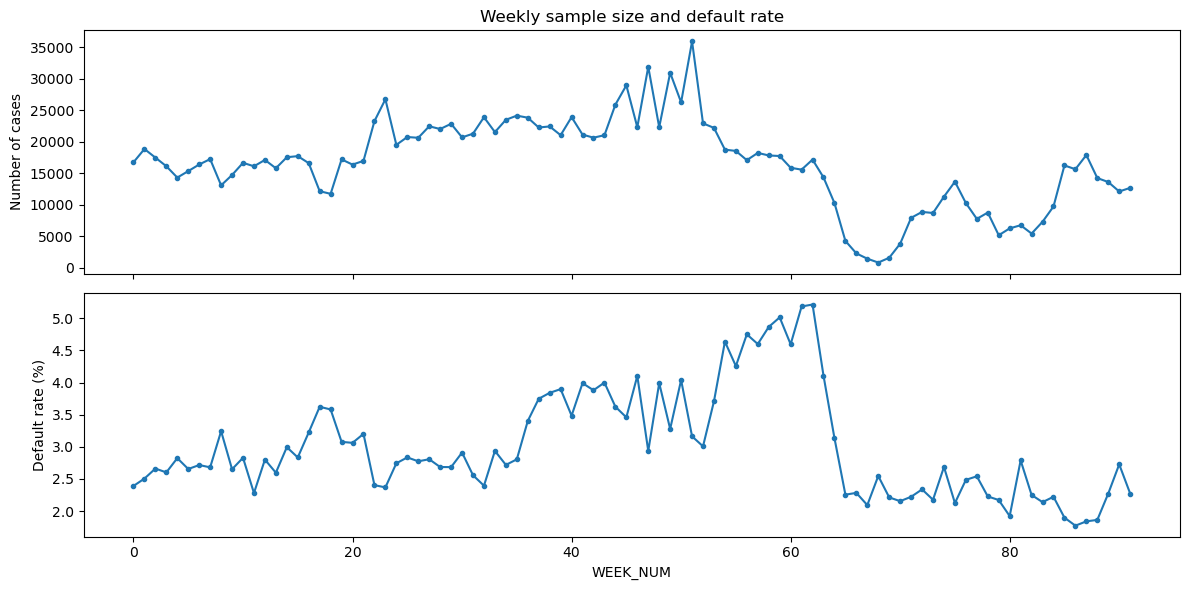

In [8]:
# 6.2 可视化每周样本量和违约率
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(
    weekly_summary["WEEK_NUM"],
    weekly_summary["n_cases"],
    marker="o",
    markersize=3,
)
axes[0].set_ylabel("Number of cases")
axes[0].set_title("Weekly sample size and default rate")

axes[1].plot(
    weekly_summary["WEEK_NUM"],
    weekly_summary["default_rate"] * 100,
    marker="o",
    markersize=3,
)
axes[1].set_xlabel("WEEK_NUM")
axes[1].set_ylabel("Default rate (%)")
plt.tight_layout()
plt.show()

In [9]:
# 7. 训练 parquet 文件地图
inventory_rows = []
for path in train_files:
    schema = pl.read_parquet_schema(path)
    columns = list(schema.keys())
    if "num_group2" in columns:
        depth = 2
    elif "num_group1" in columns:
        depth = 1
    else:
        depth = 0

    n_rows = pl.scan_parquet(path).select(pl.len()).collect().item()

    inventory_rows.append(
        {
            "file_name": path.name,
            "n_rows": n_rows,
            "n_cols": len(columns),
            "depth": depth,
            "has_case_id": "case_id" in columns,
            "has_target": "target" in columns,
        }
    )
train_inventory = (
    pl.DataFrame(inventory_rows)
    .sort(["depth", "file_name"])
)
# Notebook 输出显示设置
pl.Config.set_tbl_rows(100)
pl.Config.set_tbl_cols(20)
train_inventory

file_name,n_rows,n_cols,depth,has_case_id,has_target
str,i64,i64,i64,bool,bool
"""train_base.parquet""",1526659,5,0,true,true
"""train_static_0_0.parquet""",1003757,168,0,true,false
"""train_static_0_1.parquet""",522902,168,0,true,false
"""train_static_cb_0.parquet""",1500476,53,0,true,false
"""train_applprev_1_0.parquet""",3887684,41,1,true,false
"""train_applprev_1_1.parquet""",2638295,41,1,true,false
"""train_credit_bureau_a_1_0.parq…",4108212,79,1,true,false
"""train_credit_bureau_a_1_1.parq…",6009192,79,1,true,false
"""train_credit_bureau_a_1_2.parq…",3743810,79,1,true,false


In [10]:
# 7.1 按数据层级汇总文件规模
depth_summary = (
    train_inventory
    .group_by("depth")
    .agg(
        pl.len().alias("n_files"),
        pl.col("n_rows").sum().alias("total_raw_rows"),
        pl.col("n_cols").min().alias("min_n_cols"),
        pl.col("n_cols").max().alias("max_n_cols"),
    )
    .sort("depth")
)

depth_summary

depth,n_files,total_raw_rows,min_n_cols,max_n_cols
i64,u32,i64,i64,i64
0,4,4553794,5,168
1,14,33607298,5,79
2,14,205304104,6,19


In [11]:
# 8. 载入小表 baseline 的 depth 0 静态特征
train_static = pl.concat(
    [
        pl.read_parquet(TRAIN_DIR / "train_static_0_0.parquet"),
        pl.read_parquet(TRAIN_DIR / "train_static_0_1.parquet"),
    ],
    how="vertical",
)

train_static_cb = pl.read_parquet(
    TRAIN_DIR / "train_static_cb_0.parquet"
)

print("train_static:   ", train_static.shape)
print("train_static_cb:", train_static_cb.shape)

train_static:    (1526659, 168)
train_static_cb: (1500476, 53)


这里已经检查了depth0表能否正常拼接，检查完后代码删去，但是留了个探错代码

In [12]:
assert train_base["case_id"].n_unique() == train_base.height
assert train_static["case_id"].n_unique() == train_static.height
assert train_static_cb["case_id"].n_unique() == train_static_cb.height

开始跑最小端对端代码喵

In [13]:
# 9. 为 B0 选择静态表特征
B0_SUFFIXES = ("A", "M")

static_feature_cols = [
    col
    for col in train_static.columns
    if col[-1] in B0_SUFFIXES
]

static_cb_feature_cols = [
    col
    for col in train_static_cb.columns
    if col[-1] in B0_SUFFIXES
]

print(f"train_static B0 features: {len(static_feature_cols)}")
print(f"train_static_cb B0 features: {len(static_cb_feature_cols)}")
print("Examples from train_static:", static_feature_cols[:8])
print("Examples from train_static_cb:", static_cb_feature_cols[:8])

train_static B0 features: 39
train_static_cb B0 features: 9
Examples from train_static: ['amtinstpaidbefduel24m_4187115A', 'annuity_780A', 'annuitynextmonth_57A', 'avginstallast24m_3658937A', 'avglnamtstart24m_4525187A', 'avgoutstandbalancel6m_4187114A', 'avgpmtlast12m_4525200A', 'credamount_770A']
Examples from train_static_cb: ['description_5085714M', 'education_1103M', 'education_88M', 'maritalst_385M', 'maritalst_893M', 'pmtaverage_3A', 'pmtaverage_4527227A', 'pmtaverage_4955615A']


In [14]:
# 10. 读取 person_1 中 B0 需要的字段
train_person_1 = pl.read_parquet(
    TRAIN_DIR / "train_person_1.parquet",
    columns=[
        "case_id",
        "num_group1",
        "mainoccupationinc_384A",
        "incometype_1044T",
        "housetype_905L",
    ],
)

print(train_person_1.shape)


(2973991, 5)


In [15]:
# 11. 构造 person_1 的申请层面特征

# 同一申请下，汇总所有相关人员的信息
person_income = train_person_1.group_by("case_id").agg(
    pl.col("mainoccupationinc_384A")
    .max()
    .alias("person_income_max"),

    (pl.col("incometype_1044T") == "SELFEMPLOYED")
    .max()
    .alias("person_any_selfemployed"),
)

# 提取申请人本人的住房类型
person_housetype = (
    train_person_1
    .filter(pl.col("num_group1") == 0)
    .select(
        "case_id",
        pl.col("housetype_905L").alias("person_housetype"),
    )
)
print("person_income:", person_income.shape)
print("person_housetype:", person_housetype.shape)

person_income: (1526659, 3)
person_housetype: (1526659, 2)


In [16]:
# 12. 读取 credit_bureau_b_2 中 B0 需要的字段
train_credit_bureau_b_2 = pl.read_parquet(
    TRAIN_DIR / "train_credit_bureau_b_2.parquet",
    columns=[
        "case_id",
        "num_group1",
        "num_group2",
        "pmts_pmtsoverdue_635A",
        "pmts_dpdvalue_108P",
    ],
)

print(train_credit_bureau_b_2.shape)


(1286755, 5)


In [17]:
# 13. 构造征信逾期特征
credit_overdue = train_credit_bureau_b_2.group_by("case_id").agg(
    pl.col("pmts_pmtsoverdue_635A")
    .max()
    .alias("credit_max_overdue_payment"),

    (pl.col("pmts_dpdvalue_108P") > 31)
    .max()
    .alias("credit_has_dpd_over_31_days"),
)


In [18]:
# 14. 拼接 B0 训练数据
train_b0 = (
    train_base
    .join(
        train_static.select(["case_id"] + static_feature_cols),
        on="case_id",
        how="left",
    )
    .join(
        train_static_cb.select(["case_id"] + static_cb_feature_cols),
        on="case_id",
        how="left",
    )
    .join(
        person_income,
        on="case_id",
        how="left",
    )
    .join(
        person_housetype,
        on="case_id",
        how="left",
    )
    .join(
        credit_overdue,
        on="case_id",
        how="left",
    )
)

print("train_b0:", train_b0.shape)
assert train_b0.height == train_base.height
assert train_b0["case_id"].n_unique() == train_base.height

train_b0: (1526659, 58)


In [19]:
# 15. 检查 B0 各列的数据类型和缺失率
null_counts = train_b0.null_count().row(0)

column_profile = (
    pl.DataFrame(
        {
            "column": train_b0.columns,
            "dtype": [str(dtype) for dtype in train_b0.dtypes],
            "null_count": null_counts,
        }
    )
    .with_columns(
        (pl.col("null_count") / train_b0.height * 100)
        .round(2)
        .alias("null_pct")
    )
    .sort("null_pct", descending=True)
)
dtype_summary = (
    column_profile
    .group_by("dtype")
    .agg(pl.len().alias("n_columns"))
    .sort("n_columns", descending=True)
)

print(dtype_summary)
column_profile.head(15)

shape: (4, 2)
┌─────────┬───────────┐
│ dtype   ┆ n_columns │
│ ---     ┆ ---       │
│ str     ┆ u32       │
╞═════════╪═══════════╡
│ Float64 ┆ 37        │
│ String  ┆ 15        │
│ Int64   ┆ 4         │
│ Boolean ┆ 2         │
└─────────┴───────────┘


column,dtype,null_count,null_pct
str,str,i64,f64
"""lastotherinc_902A""","""Float64""",1523603,99.8
"""lastotherlnsexpense_631A""","""Float64""",1523601,99.8
"""credit_max_overdue_payment""","""Float64""",1490244,97.61
"""credit_has_dpd_over_31_days""","""Boolean""",1490244,97.61
"""pmtaverage_4955615A""","""Float64""",1454814,95.29
"""maxannuity_4075009A""","""Float64""",1450726,95.03
"""person_housetype""","""String""",1425841,93.4
"""pmtaverage_4527227A""","""Float64""",1411681,92.47
"""pmtaverage_3A""","""Float64""",1383070,90.59


作为B0表，已经足够出了，因为确实就那么几个特征，某些再造特征缺失率高也正常

In [20]:
# 16. 整理字段角色和数据类型

# 将日期字符串转换为真正的日期
train_b0 = train_b0.with_columns(
    pl.col("date_decision").str.to_date("%Y-%m-%d")
)

# 不作为模型输入的辅助字段
non_feature_cols = [
    "case_id",
    "date_decision",
    "MONTH",
    "WEEK_NUM",
    "target",
]
# 真正进入模型的特征
feature_cols = [
    col
    for col in train_b0.columns
    if col not in non_feature_cols
]
# 找出其中的类别特征
categorical_cols = [
    col
    for col in feature_cols
    if train_b0.schema[col] == pl.String
]
# 将字符串特征转换为类别类型
train_b0 = train_b0.with_columns(
    pl.col(categorical_cols).cast(pl.Categorical)
)
print("全部列数：", train_b0.width)
print("模型特征数：", len(feature_cols))
print("类别特征数：", len(categorical_cols))
print("类别特征：", categorical_cols)

全部列数： 58
模型特征数： 53
类别特征数： 14
类别特征： ['lastapprcommoditycat_1041M', 'lastapprcommoditytypec_5251766M', 'lastcancelreason_561M', 'lastrejectcommoditycat_161M', 'lastrejectcommodtypec_5251769M', 'lastrejectreason_759M', 'lastrejectreasonclient_4145040M', 'previouscontdistrict_112M', 'description_5085714M', 'education_1103M', 'education_88M', 'maritalst_385M', 'maritalst_893M', 'person_housetype']


In [21]:
# 17. 按时间划分训练集和验证集4：1喵

weeks = sorted(train_b0["WEEK_NUM"].unique().to_list())

split_position = int(len(weeks) * 0.8)
valid_start_week = weeks[split_position]

train_data = train_b0.filter(
    pl.col("WEEK_NUM") < valid_start_week
)

valid_data = train_b0.filter(
    pl.col("WEEK_NUM") >= valid_start_week
)

print("验证集起始周：", valid_start_week)

print(
    "训练集：",
    train_data.shape,
    f"周数 {train_data['WEEK_NUM'].min()}—{train_data['WEEK_NUM'].max()}",
    f"违约率 {train_data['target'].mean():.4f}",
)

print(
    "验证集：",
    valid_data.shape,
    f"周数 {valid_data['WEEK_NUM'].min()}—{valid_data['WEEK_NUM'].max()}",
    f"违约率 {valid_data['target'].mean():.4f}",
)

验证集起始周： 73
训练集： (1323314, 58) 周数 0—72 违约率 0.0329
验证集： (203345, 58) 周数 73—91 违约率 0.0219


差距怕是有些大，没事，先把B0跑通再说

In [22]:
# 18. 训练第一个 B0 LightGBM

import lightgbm as lgb
from sklearn.metrics import roc_auc_score

# 带有空值的 Boolean 转成数值，避免转 pandas 后成为 object
boolean_cols = [
    col
    for col in feature_cols
    if train_b0.schema[col] == pl.Boolean
]

def make_model_data(df):
    return (
        df.select(
            [
                pl.col(col).cast(pl.Int8)
                if col in boolean_cols
                else pl.col(col)
                for col in feature_cols
            ]
        )
        .to_pandas()
    )

X_train = make_model_data(train_data)
X_valid = make_model_data(valid_data)

y_train = train_data["target"].to_numpy()
y_valid = valid_data["target"].to_numpy()

# 统一训练集和验证集的类别编码
for col in categorical_cols:
    X_train[col] = (
        X_train[col]
        .astype("category")
        .cat.remove_unused_categories()
    )

    X_valid[col] = (
        X_valid[col]
        .astype("category")
        .cat.set_categories(X_train[col].cat.categories)
    )

print("X_train:", X_train.shape)
print("X_valid:", X_valid.shape)

model_b0 = lgb.LGBMClassifier(
    objective="binary",
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=100,
    colsample_bytree=0.8,
    subsample=0.8,
    subsample_freq=1,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
)

model_b0.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric="auc",
    categorical_feature=categorical_cols,
    callbacks=[
        lgb.early_stopping(stopping_rounds=100),
        lgb.log_evaluation(period=100),
    ],
)

valid_pred_b0 = model_b0.predict_proba(X_valid)[:, 1]
valid_auc_b0 = roc_auc_score(y_valid, valid_pred_b0)

print("Best iteration:", model_b0.best_iteration_)
print(f"Validation AUC: {valid_auc_b0:.6f}")

X_train: (1323314, 53)
X_valid: (203345, 53)
[LightGBM] [Info] Number of positive: 43545, number of negative: 1279769
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.188018 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 9304
[LightGBM] [Info] Number of data points in the train set: 1323314, number of used features: 50
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032906 -> initscore=-3.380640
[LightGBM] [Info] Start training from score -3.380640
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.758803	valid_0's binary_logloss: 0.0997808
[200]	valid_0's auc: 0.770713	valid_0's binary_logloss: 0.096896
[300]	valid_0's auc: 0.771051	valid_0's binary_logloss: 0.0961507
Early stopping, best iteration is:
[248]	valid_0's auc: 0.771525	valid_0's binary_logloss: 0.0964766
Best iteration: 248
Validation AUC: 0.771525


In [23]:
# 19. 计算逐周 Gini 和稳定性分数

import numpy as np
import pandas as pd

valid_score = (
    valid_data
    .select(["WEEK_NUM", "target"])
    .to_pandas()
)

valid_score["score"] = valid_pred_b0

weekly_results = []

for week, week_data in valid_score.groupby("WEEK_NUM", sort=True):

    # 如果某一周只有一种标签，就无法计算 AUC
    if week_data["target"].nunique() < 2:
        continue

    week_auc = roc_auc_score(
        week_data["target"],
        week_data["score"],
    )

    week_gini = 2 * week_auc - 1

    weekly_results.append(
        {
            "WEEK_NUM": week,
            "n_cases": len(week_data),
            "default_rate": week_data["target"].mean(),
            "auc": week_auc,
            "gini": week_gini,
        }
    )

weekly_gini = pd.DataFrame(weekly_results)

# 按比赛公式拟合每周 Gini 的时间趋势
x = np.arange(len(weekly_gini), dtype=float)
y = weekly_gini["gini"].to_numpy()

slope, intercept = np.polyfit(x, y, 1)
gini_trend = slope * x + intercept
residual_std = np.std(y - gini_trend)
mean_gini = np.mean(y)

stability_score_b0 = (
    mean_gini
    + 88.0 * min(0, slope)
    - 0.5 * residual_std
)

weekly_gini["gini_trend"] = gini_trend

print(f"Mean weekly Gini: {mean_gini:.6f}")
print(f"Gini slope:       {slope:.6f}")
print(f"Residual std:     {residual_std:.6f}")
print(f"Stability score:  {stability_score_b0:.6f}")

weekly_gini

Mean weekly Gini: 0.538561
Gini slope:       0.000103
Residual std:     0.030731
Stability score:  0.523196


,WEEK_NUM,n_cases,default_rate,auc,gini,gini_trend
0,73,8687,0.021757,0.767530,0.535061,0.537634
1,74,11280,0.026862,0.779839,0.559678,0.537737
2,75,13656,0.021236,0.777654,0.555307,0.537840
3,76,10261,0.024851,0.778695,0.557390,0.537943
4,77,7754,0.025406,0.754441,0.508881,0.538046
5,78,8755,0.022273,0.787720,0.575440,0.538149
6,79,5158,0.021714,0.782426,0.564852,0.538252
7,80,6246,0.019212,0.764212,0.528424,0.538355
8,81,6743,0.027881,0.740984,0.481968,0.538458
9,82,5423,0.022497,0.733781,0.467561,0.538561


表格还是太难看了还好有ai绘图

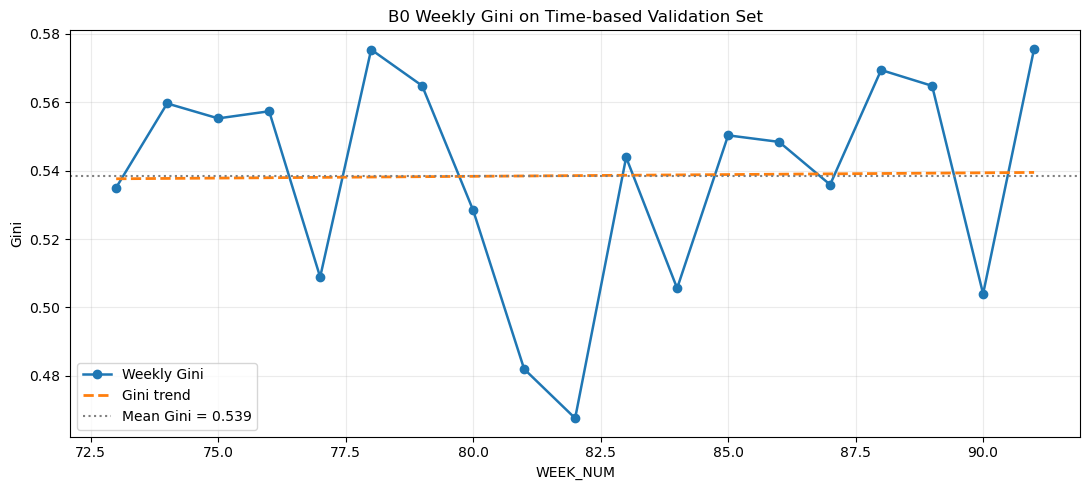

表现最低的3周：


,WEEK_NUM,n_cases,default_rate,auc,gini
9,82,5423,0.022497,0.733781,0.467561
8,81,6743,0.027881,0.740984,0.481968
17,90,12103,0.027266,0.751981,0.503963


In [24]:
# 20. 绘制验证期逐周 Gini

plt.figure(figsize=(11, 5))

plt.plot(
    weekly_gini["WEEK_NUM"],
    weekly_gini["gini"],
    marker="o",
    linewidth=1.8,
    label="Weekly Gini",
)

plt.plot(
    weekly_gini["WEEK_NUM"],
    weekly_gini["gini_trend"],
    linestyle="--",
    linewidth=2,
    label="Gini trend",
)

plt.axhline(
    mean_gini,
    color="gray",
    linestyle=":",
    label=f"Mean Gini = {mean_gini:.3f}",
)

plt.title("B0 Weekly Gini on Time-based Validation Set")
plt.xlabel("WEEK_NUM")
plt.ylabel("Gini")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

print("表现最低的3周：")
display(
    weekly_gini
    .nsmallest(3, "gini")[
        ["WEEK_NUM", "n_cases", "default_rate", "auc", "gini"]
    ]
)

,feature,gain,split,gain_pct
0,previouscontdistrict_112M,154672.027208,2845,23.478767
1,lastrejectreason_759M,74891.506060,99,11.368314
2,amtinstpaidbefduel24m_4187115A,60983.138329,437,9.257064
3,lastcancelreason_561M,42518.860729,133,6.454240
4,price_1097A,34435.735275,365,5.227245
5,pmtssum_45A,30817.235754,256,4.677967
6,pmtaverage_3A,26079.113863,184,3.958734
7,maxannuity_159A,22539.537758,285,3.421437
8,education_1103M,16896.790203,144,2.564884
9,totalsettled_863A,16059.671001,223,2.437812


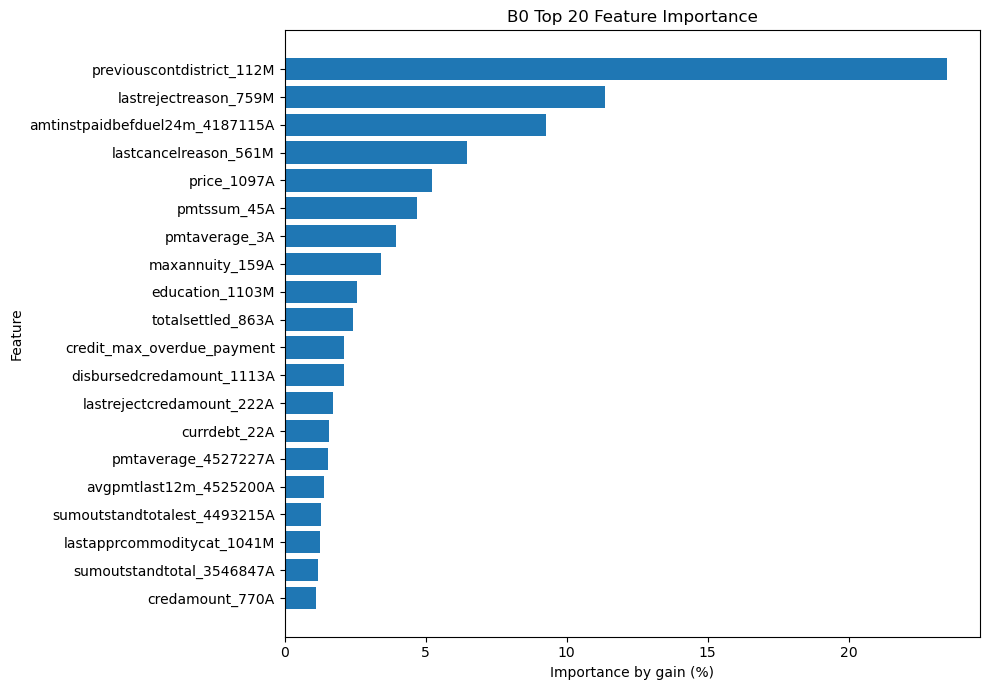

In [25]:
# 21. 查看 B0 特征重要性

importance_b0 = pd.DataFrame(
    {
        "feature": model_b0.booster_.feature_name(),
        "gain": model_b0.booster_.feature_importance(
            importance_type="gain"
        ),
        "split": model_b0.booster_.feature_importance(
            importance_type="split"
        ),
    }
)

importance_b0["gain_pct"] = (
    importance_b0["gain"]
    / importance_b0["gain"].sum()
    * 100
)

importance_b0 = importance_b0.sort_values(
    "gain",
    ascending=False,
).reset_index(drop=True)

display(importance_b0.head(20))

top20 = (
    importance_b0
    .head(20)
    .sort_values("gain_pct")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top20["feature"],
    top20["gain_pct"],
)

plt.title("B0 Top 20 Feature Importance")
plt.xlabel("Importance by gain (%)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [26]:
# 22. 读取官方特征定义

feature_definitions = pl.read_csv(
    DATA_ROOT / "feature_definitions.csv"
)

print(feature_definitions.columns)
print(feature_definitions.shape)


['Variable', 'Description']
(465, 2)


In [27]:
# 23. 合并特征重要性与官方定义

importance_with_definition = (
    pl.from_pandas(importance_b0)
    .join(
        feature_definitions,
        left_on="feature",
        right_on="Variable",
        how="left",
    )
    .select(
        [
            "feature",
            "Description",
            "gain_pct",
            "gain",
            "split",
        ]
    )
)

importance_with_definition.head(20)

feature,Description,gain_pct,gain,split
str,str,f64,f64,i32
"""previouscontdistrict_112M""","""Contact district of the client…",23.478767,154672.027208,2845
"""lastrejectreason_759M""","""Reason for rejection on the mo…",11.368314,74891.50606,99
"""amtinstpaidbefduel24m_4187115A""","""Number of instalments paid bef…",9.257064,60983.138329,437
"""lastcancelreason_561M""","""Cancellation reason of the las…",6.45424,42518.860729,133
"""price_1097A""","""Credit price.""",5.227245,34435.735275,365
"""pmtssum_45A""","""Sum of tax deductions for the …",4.677967,30817.235754,256
"""pmtaverage_3A""","""Average of tax deductions.""",3.958734,26079.113863,184
"""maxannuity_159A""","""Maximum annuity previously obt…",3.421437,22539.537758,285
"""education_1103M""","""Level of education of the clie…",2.564884,16896.790203,144


第一个特征占比太大了，于是果断选择两个路；
比如可能因为test集波动性大，也可能因为就是这个特征非常特殊，所以设置对照实验

In [28]:
# 24. 检查 previouscontdistrict_112M 的时间分布漂移

focus_feature = "previouscontdistrict_112M"

# 1. 基础画像：类别数和缺失率
def feature_summary(df, split_name):
    return df.select(
        pl.lit(split_name).alias("split"),
        pl.len().alias("n_rows"),
        pl.col(focus_feature)
        .drop_nulls()
        .n_unique()
        .alias("n_categories"),
        pl.col(focus_feature)
        .null_count()
        .alias("null_count"),
        (
            pl.col(focus_feature).null_count()
            / pl.len()
            * 100
        )
        .round(3)
        .alias("null_pct"),
    )

summary = pl.concat(
    [
        feature_summary(train_data, "train"),
        feature_summary(valid_data, "valid"),
    ],
    how="vertical",
)

print("基础画像：")
display(summary)


# 2. 检查验证期是否出现训练期没有的新类别
train_categories = set(
    train_data[focus_feature]
    .cast(pl.String)
    .drop_nulls()
    .unique()
    .to_list()
)

valid_categories = set(
    valid_data[focus_feature]
    .cast(pl.String)
    .drop_nulls()
    .unique()
    .to_list()
)

unseen_categories = valid_categories - train_categories

print("训练期类别数：", len(train_categories))
print("验证期类别数：", len(valid_categories))
print("验证期新类别数：", len(unseen_categories))


# 3. 分别统计训练期和验证期的类别占比
def category_distribution(df, prefix):
    return (
        df.select(
            pl.col(focus_feature)
            .cast(pl.String)
            .fill_null("__MISSING__")
            .alias(focus_feature)
        )
        .group_by(focus_feature)
        .agg(
            pl.len().alias(f"{prefix}_count")
        )
        .with_columns(
            (
                pl.col(f"{prefix}_count")
                / df.height
            ).alias(f"{prefix}_share")
        )
    )

train_dist = category_distribution(train_data, "train")
valid_dist = category_distribution(valid_data, "valid")

drift_table = (
    train_dist
    .join(
        valid_dist,
        on=focus_feature,
        how="full",
        coalesce=True,
    )
    .with_columns(
        pl.col("train_count").fill_null(0),
        pl.col("valid_count").fill_null(0),
        pl.col("train_share").fill_null(0.0),
        pl.col("valid_share").fill_null(0.0),
    )
)


# 4. 计算每个类别对 PSI 的贡献
epsilon = 1e-6

drift_table = (
    drift_table
    .with_columns(
        (
            (
                pl.col("valid_share") + epsilon
                - pl.col("train_share") - epsilon
            )
            * (
                (
                    pl.col("valid_share") + epsilon
                )
                / (
                    pl.col("train_share") + epsilon
                )
            ).log()
        ).alias("psi_component"),

        (
            (
                pl.col("valid_share")
                - pl.col("train_share")
            )
            * 100
        ).alias("share_change_pct"),
    )
)

district_psi = drift_table["psi_component"].sum()

print(f"Categorical PSI: {district_psi:.6f}")

print("漂移贡献最大的15个类别：")
display(
    drift_table
    .sort("psi_component", descending=True)
    .select(
        [
            focus_feature,
            "train_count",
            "valid_count",
            "train_share",
            "valid_share",
            "share_change_pct",
            "psi_component",
        ]
    )
    .head(15)
)

基础画像：


split,n_rows,n_categories,null_count,null_pct
str,u32,u32,u32,f64
"""train""",1323314,223,0,0.0
"""valid""",203345,223,0,0.0


训练期类别数： 223
验证期类别数： 223
验证期新类别数： 0
Categorical PSI: 0.135840
漂移贡献最大的15个类别：


previouscontdistrict_112M,train_count,valid_count,train_share,valid_share,share_change_pct,psi_component
str,u32,u32,f64,f64,f64,f64
"""a55475b1""",436830,51598,0.330103,0.253746,-7.635696,0.020087
"""P82_15_54""",215,781,0.000162,0.003841,0.367829,0.011613
"""P109_39_170""",79,463,0.00006,0.002277,0.221722,0.008038
"""P74_104_25""",41,251,0.000031,0.001234,0.120337,0.004397
"""P110_60_165""",52,252,0.000039,0.001239,0.119998,0.004112
"""P136_95_178""",47,241,0.000036,0.001185,0.114966,0.004002
"""P21_87_50""",40,228,0.00003,0.001121,0.109102,0.003908
"""P73_74_80""",37,224,0.000028,0.001102,0.107362,0.003907
"""P131_33_167""",54337,6062,0.041061,0.029811,-1.12499,0.003602


In [29]:
# 25. 检查地区与违约风险关系是否稳定

def category_target_stats(df, prefix):
    return (
        df.select(
            pl.col(focus_feature)
            .cast(pl.String)
            .alias(focus_feature),
            "target",
        )
        .group_by(focus_feature)
        .agg(
            pl.len().alias(f"{prefix}_count"),
            pl.col("target")
            .mean()
            .alias(f"{prefix}_default_rate"),
        )
    )

train_target_stats = category_target_stats(
    train_data,
    "train",
)

valid_target_stats = category_target_stats(
    valid_data,
    "valid",
)

train_global_rate = train_data["target"].mean()
valid_global_rate = valid_data["target"].mean()

district_risk_stability = (
    train_target_stats
    .join(
        valid_target_stats,
        on=focus_feature,
        how="inner",
    )
    .with_columns(
        (
            pl.col("train_default_rate")
            / train_global_rate
        ).alias("train_risk_lift"),

        (
            pl.col("valid_default_rate")
            / valid_global_rate
        ).alias("valid_risk_lift"),
    )
    .with_columns(
        (
            pl.col("valid_risk_lift")
            - pl.col("train_risk_lift")
        )
        .abs()
        .alias("abs_lift_change")
    )
)

# 排除样本过少、违约率极容易随机波动的类别
reliable_districts = district_risk_stability.filter(
    (pl.col("train_count") >= 1000)
    & (pl.col("valid_count") >= 200)
)

reliable_pd = reliable_districts.to_pandas()

spearman_corr = reliable_pd[
    "train_risk_lift"
].corr(
    reliable_pd["valid_risk_lift"],
    method="spearman",
)

same_risk_side_pct = (
    (
        (
            reliable_pd["train_risk_lift"] - 1
        )
        * (
            reliable_pd["valid_risk_lift"] - 1
        )
        >= 0
    )
    .mean()
    * 100
)

print("进入稳定性比较的地区数：", len(reliable_pd))
print(f"风险排序 Spearman 相关：{spearman_corr:.4f}")
print(
    f"高/低风险方向一致比例："
    f"{same_risk_side_pct:.2f}%"
)

print("风险关系变化最大的15个地区：")

display(
    reliable_districts
    .sort("abs_lift_change", descending=True)
    .select(
        [
            focus_feature,
            "train_count",
            "valid_count",
            "train_default_rate",
            "valid_default_rate",
            "train_risk_lift",
            "valid_risk_lift",
            "abs_lift_change",
        ]
    )
    .head(15)
)

进入稳定性比较的地区数： 161
风险排序 Spearman 相关：0.3252
高/低风险方向一致比例：62.73%
风险关系变化最大的15个地区：


previouscontdistrict_112M,train_count,valid_count,train_default_rate,valid_default_rate,train_risk_lift,valid_risk_lift,abs_lift_change
str,u32,u32,f64,f64,f64,f64,f64
"""P170_5_78""",3434,689,0.053582,0.007257,1.628329,0.331682,1.296647
"""P54_85_123""",1379,202,0.040609,0.00495,1.234094,0.226266,1.007828
"""P16_146_184""",2060,417,0.052427,0.014388,1.59324,0.657637,0.935603
"""P41_138_103""",2501,399,0.022391,0.035088,0.680454,1.603711,0.923257
"""P201_161_109""",2282,403,0.040754,0.047146,1.238488,2.154863,0.916375
"""P49_60_127""",1068,224,0.049625,0.013393,1.508097,0.612131,0.895966
"""P164_163_178""",3649,793,0.054261,0.055485,1.648982,2.536008,0.887026
"""P40_31_175""",1095,220,0.032877,0.040909,0.999109,1.869782,0.870672
"""P217_42_163""",1152,252,0.046007,0.011905,1.398131,0.544116,0.854015


In [30]:
# 26. 消融实验：移除 previouscontdistrict_112M 后重新训练
from sklearn.base import clone
from sklearn.metrics import roc_auc_score
import lightgbm as lgb

DROP_COL = "previouscontdistrict_112M"

X_train_no_district = X_train.drop(columns=[DROP_COL])
X_valid_no_district = X_valid.drop(columns=[DROP_COL])

print("原始特征数:", X_train.shape[1])
print("移除后特征数:", X_train_no_district.shape[1])

# 复制原模型的全部参数，但不保留已经训练出的树
model_no_district = clone(model_b0)

model_no_district.fit(
    X_train_no_district,
    y_train,
    eval_set=[(X_valid_no_district, y_valid)],
    eval_metric=["auc", "binary_logloss"],
    callbacks=[
        lgb.early_stopping(100),
        lgb.log_evaluation(100),
    ],
)

valid_pred_no_district = model_no_district.predict_proba(
    X_valid_no_district
)[:, 1]

auc_no_district = roc_auc_score(y_valid, valid_pred_no_district)

print("原模型 Validation AUC:", round(0.771525, 6))
print("移除地区特征后的 AUC:", round(auc_no_district, 6))
print("AUC 变化:", round(auc_no_district - 0.771525, 6))
print("Best iteration:", model_no_district.best_iteration_)

原始特征数: 53
移除后特征数: 52
[LightGBM] [Info] Number of positive: 43545, number of negative: 1279769
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.061142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 9093
[LightGBM] [Info] Number of data points in the train set: 1323314, number of used features: 49
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032906 -> initscore=-3.380640
[LightGBM] [Info] Start training from score -3.380640
Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.76715	valid_0's binary_logloss: 0.0987721
[200]	valid_0's auc: 0.776287	valid_0's binary_logloss: 0.0960891
[300]	valid_0's auc: 0.776924	valid_0's binary_logloss: 0.0953255
[400]	valid_0's auc: 0.777468	valid_0's binary_logloss: 0.0951081
[500]	valid_0's auc: 0.778015	valid_0's binary_logloss: 0.0949539
[600]	valid_0's auc: 0.778

In [31]:
# 27. 计算移除 previouscontdistrict_112M 后的逐周 Gini 和稳定性分数

valid_score_no_district = (
    valid_data
    .select(["WEEK_NUM", "target"])
    .to_pandas()
)

# 使用消融模型的验证集预测
valid_score_no_district["score"] = valid_pred_no_district

weekly_results_no_district = []

for week, week_data in valid_score_no_district.groupby(
    "WEEK_NUM",
    sort=True,
):

    # 某一周只有一种标签时，无法计算 AUC
    if week_data["target"].nunique() < 2:
        continue

    week_auc = roc_auc_score(
        week_data["target"],
        week_data["score"],
    )

    week_gini = 2 * week_auc - 1

    weekly_results_no_district.append(
        {
            "WEEK_NUM": week,
            "n_cases": len(week_data),
            "default_rate": week_data["target"].mean(),
            "auc": week_auc,
            "gini": week_gini,
        }
    )

weekly_gini_no_district = pd.DataFrame(
    weekly_results_no_district
)

# 拟合逐周 Gini 的时间趋势
x_no_district = np.arange(
    len(weekly_gini_no_district),
    dtype=float,
)

y_no_district = (
    weekly_gini_no_district["gini"]
    .to_numpy()
)

slope_no_district, intercept_no_district = np.polyfit(
    x_no_district,
    y_no_district,
    1,
)

gini_trend_no_district = (
    slope_no_district * x_no_district
    + intercept_no_district
)

residual_std_no_district = np.std(
    y_no_district - gini_trend_no_district
)

mean_gini_no_district = np.mean(y_no_district)

stability_score_no_district = (
    mean_gini_no_district
    + 88.0 * min(0, slope_no_district)
    - 0.5 * residual_std_no_district
)

weekly_gini_no_district["gini_trend"] = (
    gini_trend_no_district
)

print("移除地区特征后的结果：")
print(
    f"Mean weekly Gini: "
    f"{mean_gini_no_district:.6f}"
)
print(
    f"Gini slope:       "
    f"{slope_no_district:.6f}"
)
print(
    f"Residual std:     "
    f"{residual_std_no_district:.6f}"
)
print(
    f"Stability score:  "
    f"{stability_score_no_district:.6f}"
)

weekly_gini_no_district

移除地区特征后的结果：
Mean weekly Gini: 0.552070
Gini slope:       0.000070
Residual std:     0.033676
Stability score:  0.535232


,WEEK_NUM,n_cases,default_rate,auc,gini,gini_trend
0,73,8687,0.021757,0.771144,0.542288,0.551438
1,74,11280,0.026862,0.780790,0.561580,0.551508
2,75,13656,0.021236,0.785273,0.570547,0.551578
3,76,10261,0.024851,0.799342,0.598684,0.551649
4,77,7754,0.025406,0.758254,0.516508,0.551719
5,78,8755,0.022273,0.799923,0.599845,0.551789
6,79,5158,0.021714,0.787977,0.575955,0.551859
7,80,6246,0.019212,0.768171,0.536341,0.551929
8,81,6743,0.027881,0.742158,0.484316,0.552000
9,82,5423,0.022497,0.743429,0.486858,0.552070


In [32]:
# 28. 比较原始 B0 与移除地区特征后的结果

comparison = pd.DataFrame(
    {
        "metric": [
            "Validation AUC",
            "Mean weekly Gini",
            "Gini slope",
            "Residual std",
            "Stability score",
        ],
        "B0": [
            roc_auc_score(y_valid, valid_pred_b0),
            mean_gini,
            slope,
            residual_std,
            stability_score_b0,
        ],
        "B0_no_district": [
            roc_auc_score(
                y_valid,
                valid_pred_no_district,
            ),
            mean_gini_no_district,
            slope_no_district,
            residual_std_no_district,
            stability_score_no_district,
        ],
    }
)

comparison["change"] = (
    comparison["B0_no_district"]
    - comparison["B0"]
)

comparison

,metric,B0,B0_no_district,change
0,Validation AUC,0.771525,0.778251,0.006726
1,Mean weekly Gini,0.538561,0.552070,0.013509
2,Gini slope,0.000103,0.000070,-0.000033
3,Residual std,0.030731,0.033676,0.002945
4,Stability score,0.523196,0.535232,0.012036


In [33]:
# 29. 查看稳定版 B0 的特征重要性

importance_b0_stable = pd.DataFrame(
    {
        "feature": X_train_no_district.columns,
        "gain": model_no_district.booster_.feature_importance(
            importance_type="gain"
        ),
        "split": model_no_district.booster_.feature_importance(
            importance_type="split"
        ),
    }
)

importance_b0_stable["gain_pct"] = (
    importance_b0_stable["gain"]
    / importance_b0_stable["gain"].sum()
    * 100
)

importance_b0_stable = (
    importance_b0_stable
    .sort_values("gain", ascending=False)
    .reset_index(drop=True)
)

importance_b0_stable.head(20)

,feature,gain,split,gain_pct
0,lastrejectreason_759M,72838.085944,241,10.497749
1,amtinstpaidbefduel24m_4187115A,70740.235097,1101,10.195397
2,lastcancelreason_561M,53080.509744,584,7.650199
3,price_1097A,44804.581964,990,6.457435
4,pmtssum_45A,36433.055468,686,5.250894
5,maxannuity_159A,31780.250191,865,4.580311
6,pmtaverage_3A,29585.467302,380,4.263989
7,totalsettled_863A,25560.024801,726,3.683824
8,disbursedcredamount_1113A,18719.680444,417,2.697964
9,education_1103M,18005.533830,227,2.595038


In [34]:
# 30. 固化稳定版 B0

model_b0_final = model_no_district

X_train_b0_final = X_train_no_district
X_valid_b0_final = X_valid_no_district

valid_pred_b0_final = valid_pred_no_district

print("B0 final 已确定")
print("特征数:", X_train_b0_final.shape[1])
print("Validation AUC:", round(auc_no_district, 6))
print(
    "Stability score:",
    round(stability_score_no_district, 6),
)

B0 final 已确定
特征数: 52
Validation AUC: 0.778251
Stability score: 0.535232
